<a href="https://colab.research.google.com/github/diablo-10/ML-laab/blob/main/decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import urllib.request

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

# Dataset source URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
file_name = "Online Retail.xlsx"

# Download the file if it does not exist
if not os.path.exists(file_name):
    print(f"'{file_name}' not found locally. Downloading from UCI Repository...")
    try:
        urllib.request.urlretrieve(url, file_name)
        print("Download complete.")
    except Exception as e:
        raise RuntimeError(f"Failed to download the dataset automatically: {e}. Please upload 'Online Retail.xlsx' manually to the session storage.")

# Load dataset
df = pd.read_excel(file_name)

# Remove missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Remove invalid transactions
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]

# Calculate total amount
df["TotalAmount"] = df["Quantity"] * df["UnitPrice"]

# Customer-level aggregation
customer_data = df.groupby("CustomerID").agg({
    "Quantity": "sum",
    "TotalAmount": "sum",
    "InvoiceNo": "nunique"
}).reset_index()

customer_data.columns = [
    "CustomerID", "TotalQuantity",
    "TotalAmount", "NumberOfInvoices"
]

# Create customer segment
median_amount = customer_data["TotalAmount"].median()
customer_data["Segment"] = (
    customer_data["TotalAmount"] >= median_amount
).astype(int)

# Features and target
X = customer_data[["TotalQuantity", "NumberOfInvoices"]]
y = customer_data["Segment"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ID3 Decision Tree
model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
model.fit(X_train, y_train)


'Online Retail.xlsx' not found locally. Downloading from UCI Repository...
Download complete.


DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

Model Accuracy: 0.9032

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       434
           1       0.89      0.92      0.90       434

    accuracy                           0.90       868
   macro avg       0.90      0.90      0.90       868
weighted avg       0.90      0.90      0.90       868



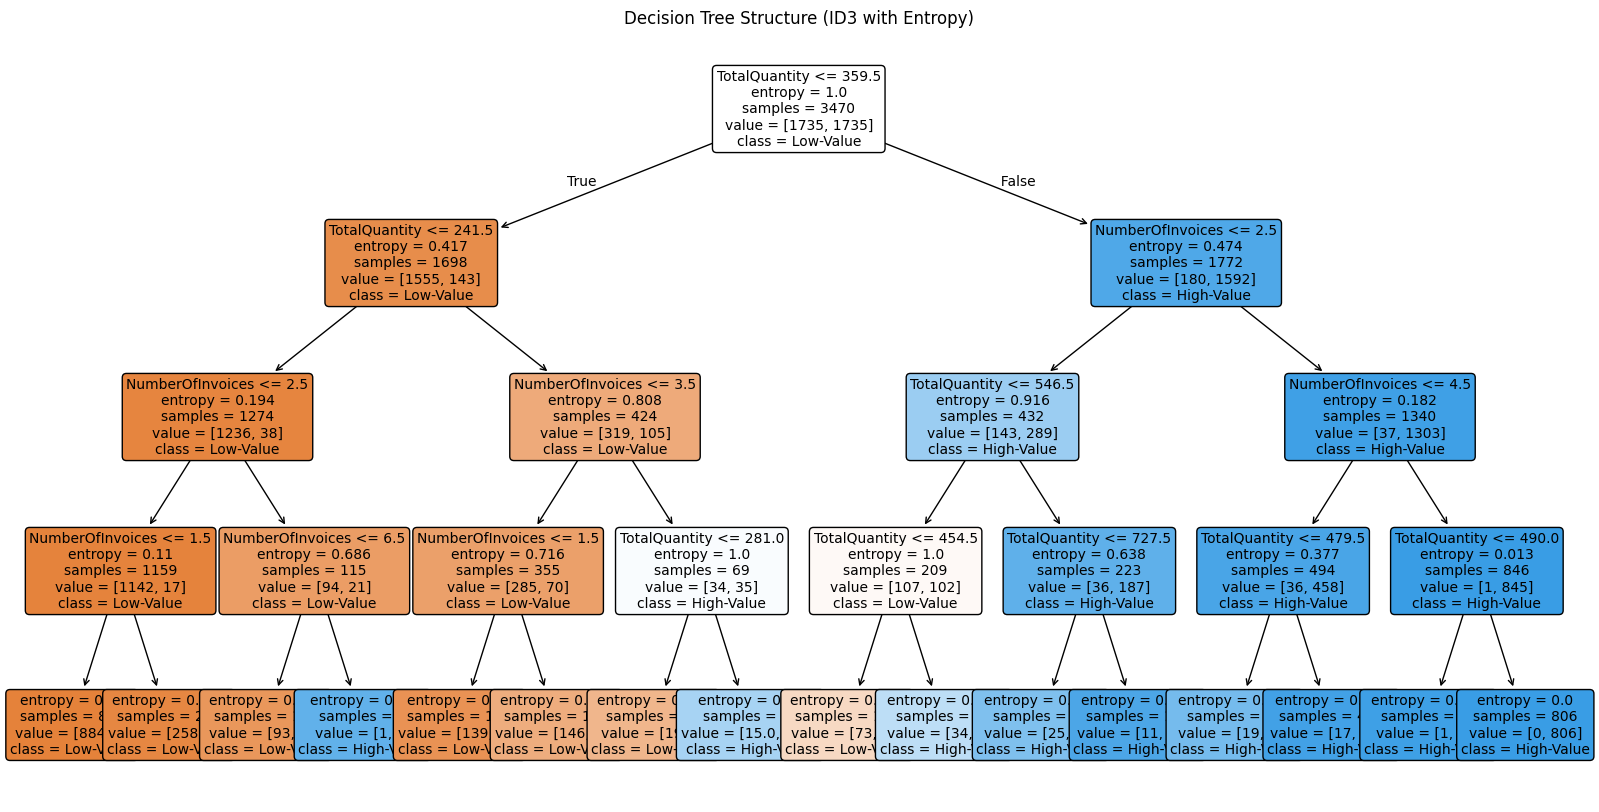

In [2]:
# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Low-Value", "High-Value"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure (ID3 with Entropy)")
plt.show()